
# Mass-spring system behaviour with no external influence (2nd-Order linear homogenous ODE)

**Methods:** Analytical solution via the characteristic equation (four damping regimes), NumPy, Matplotlib

### Overview
This notebook examines how the damping coefficient of a mass-spring system changes its motion across four regimes (undamped, under-, critical, over-damped).

---


### The role of dampers:

Four mass-spring-damper system configurations are listed below. Using the general solutions for the mass-spring system and the corresponding solution types for the second-order linear homogeneous ODE, this notebook investigates the behavior of each system through the following analyses:

1. Analyze the motion of the mass body by plotting its displacement ($X$) and velocity ($X'$) over time. The system starts with an initial displacement of 1 m ($X_{t=0}=X_0=1.0$ m, Dirichlet condition) and no initial velocity ($X'_{t=0}=X'_0=0.0$ m/s, Neumann condition). The positive direction of $X$ is defined as downward from the equilibrium position, which should be considered when interpreting the time-series plot. The system is analyzed over a 15-s period with a time interval of 0.1 s.

2. Using the same initial conditions, examine the relationship between the mass body's position and velocity ($X'$) over time by constructing a phase diagram. The horizontal axis represents the body's velocity, while the vertical axis represents its position.

| Set-up | Mass, $m$ \[kg\] | Spring constant, $k$ \[kg/s$^2$\] | Resistance coefficient, $c$ \[kg/s\] |
|  :---:   | :---: | :---: | :---: |
| (1) | 1.0 | 1.0 | 0.0 |
| (2) | 1.0 | 1.0 | 1.0 |
| (3) | 1.0 | 1.0 | 2.0 |
| (4) | 1.0 | 1.0 | 3.0 |

Summary of solutions for $X$ under various conditions of internal parameters ($c_p$, $\omega_p$):

$\frac{d^2X}{dt^2} + c_p\frac{dX}{dt}+\omega^2_pX = 0 $

$c_p=\frac{c}{m} $

$\omega_p=\sqrt{\frac{k}{m}}$

</br>

| Solution type |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Form of solution &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Physical phenomena |
|---|:---------------:|---|
|Imaginary<br/>($c_p=0$) | $X=X_0\cos{\omega_pt}$<br/>$(\lambda = \pm i\omega_p)$ | Natural vibration |
|Imaginary<br/>($c_p<2\omega_p$) | $X=X_0e^{pt}(\cos{qt}-(p/q)\sin{qt})$<br/>$(\lambda = p\pm iq)$ | Underdamping |
|Double root<br/>($c_p=2\omega_p$) | $X=X_0(1-\alpha t)e^{\alpha t}$<br/>$(\lambda = \alpha)$ | Critical damping |
|Distinct roots<br/>($c_p>2\omega_p$) | $X=X_0(\alpha - \beta)^{-1}(-\beta e^{\alpha t} + \alpha e^{\beta t})$<br/>$(\lambda = \alpha , \beta)$ | Overdamping |

---

#### Importing necessary modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#### Assigning the parameters and the time (`t`) array.

In [2]:
m = 1.0
k = 1.0
wp = np.sqrt(k/m)
dt = 0.1
t = np.arange(0.0,15.0+dt,dt)

#### Define functions that vary depending on the relationship of the internal parameters.

In [3]:
def undamped(t,Xo,wp,cp):
  X = Xo * np.cos(wp*t)
  V = -wp * Xo * np.sin(wp *t)
  return X,V,"undamped"

def underdamped(t,Xo,wp,cp):
  p = -cp/2
  q = np.sqrt(-(cp**2 - 4*(wp**2)))/2
  X = Xo * np.exp(p*t) * (np.cos(q*t) - (p/q) * np.sin(q*t))
  V = -Xo * np.exp(p * t) * ((p**2 + q**2) / q) * np.sin(q * t)
  return X,V, "underdamped"

def critical(t,Xo,wp,cp):
  al = -cp/2
  X = Xo * (1 - al * t) * np.exp(al * t)
  V = -Xo * (al**2) * t * np.exp(al * t)
  return X,V, "critical"

def overdamped(t,Xo,wp,cp):
  a = (-cp + np.sqrt(cp**2-4 * wp**2))/2
  b = (-cp - np.sqrt(cp**2-4 * wp**2))/2
  X = Xo * (a-b)**(-1)*(-b * np.exp(a * t)+a * np.exp(b*t))
  V = Xo * (1 / (a - b)) * (-b * a * np.exp(a * t) + a * b * np.exp(b * t))
  return X,V, "overdamped"

def solve(t,Xo,wp,cp):
  if cp == 0:
    X,V,label = undamped(t,Xo,wp,cp)
  elif cp < 2.0*wp:
    X,V,label = underdamped(t,Xo,wp,cp)
  elif cp == 2.0*wp:
    X,V,label = critical(t,Xo,wp,cp)
  elif cp > 2.0*wp:
    X,V,label = overdamped(t,Xo,wp,cp)
  return X, V, label

As described above, the `solve` function is required to classify the type of solution based on the roots of the characteristic equation. The solution can be classified as imaginary roots with or without a real part, a double root, or distinct roots. The corresponding form of the solution can then be selected for easier calculation.

After obtaining the appropriate form of the displacement equation ($X$), the equation is differentiated with respect to time to determine the rate of change of displacement, $\frac{dX}{dt}$. This represents the velocity of the mass body, which can be written as $X'$ or $V$.


#### Applying the function to a resistance coefficient.

Now let's define new function for resistance to add $c_p$ term ($c_p\frac{dX}{dt}$) in to the calculation.

In [4]:
def resistance(c):
  cp=c/m
  Xtarget, Vtarget, label = solve(t,1.0,wp,cp=c/m)
  return Xtarget, Vtarget, label

Notice that the solution provides three outputs: `Xtarget`, `Vtarget`, and `label`, as specified by `return Xtarget, Vtarget, label` in the `resistance` function above. This function internally uses the `solve` function to determine the appropriate solution. The `label` output is used only to identify the type of damping applied to the system.

#### Plotting the solution

Drawing the time series is as simple as the following code.

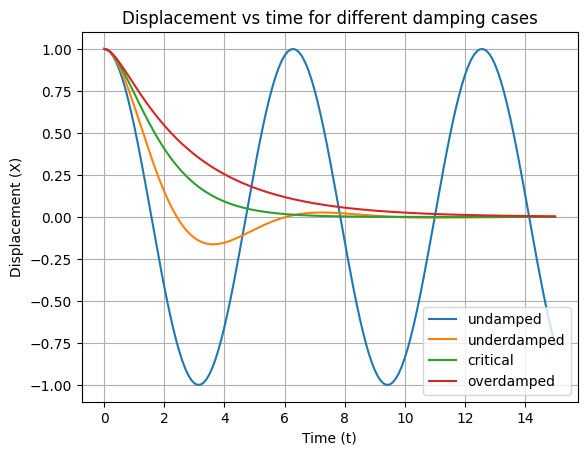

In [5]:
for c in range(0, 4, 1):
    Xtarget, Vtarget, label = resistance(c)
    plt.plot(t, Xtarget, label = label)
plt.legend()
plt.xlabel("Time (t)")
plt.ylabel("Displacement (X)")
plt.title('Displacement vs time for different damping cases')
plt.grid(True)
plt.legend()

As we can see from the graphs, even a small difference in the system's resistance can result in a significantly different behavior compared to natural vibration (no resistance/ideal case).

The undamped graph has $c_p=0$, meaning there is no friction during oscillation, so the spring continues oscillating forever.

For the underdamped case, there is a $c_p$ term, but its value is not large enough to make the square root term greater than 0, resulting in imaginary roots. This causes the form of the solution to contain sin-cos terms, allowing the displacement to cross 0 and move further before returning to equilibrium. Simply put, the friction is not strong enough to stop the spring system before it passes the equilibrium point.

For the critical and overdamped cases, these two graphs are quite similar because neither crosses 0 (the equilibrium position) anymore, since their forms of solution do not contain sin-cos terms. However, critical damping is the fastest possible non-oscillatory motion that returns to equilibrium, while overdamping is slower due to stronger damping.


For the phase diagram,

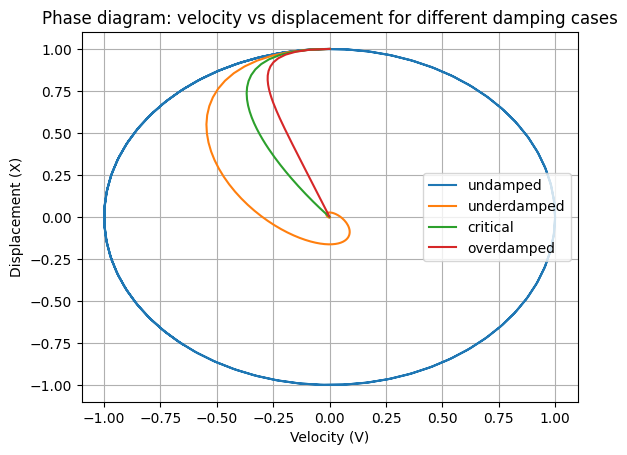

In [6]:
for c in range(0, 4, 1):
    Xtarget, Vtarget, label = resistance(c)
    plt.plot(Vtarget, Xtarget, label = label)
plt.legend()
plt.xlabel("Velocity (V)")
plt.ylabel("Displacement (X)")
plt.title('Phase diagram: velocity vs displacement for different damping cases')
plt.grid(True)
plt.legend()

From the graph, all cases start at $(0.00, 1.00)$, meaning the system begins with a displacement of 1 and a velocity of 0.

The undamped case forms an ellipse, indicating continuous oscillation without energy loss or friction. The velocity and displacement continuously increase and decrease, and the system never settles because there is no resistance $c$ to remove energy from the motion.

The underdamped case forms a spiraling curve that gradually shrinks toward the origin $(0.00, 0.00)$. This shows that the system still oscillates, but the amplitude of both velocity and displacement decreases over time due to damping. The system eventually reaches equilibrium, while still crossing $X=0$ multiple times before settling.

For the critically damped and overdamped cases, neither system oscillates. Instead, both move directly toward the origin. The critically damped system reaches the origin in the shortest possible time without overshooting, while the overdamped system takes longer due to stronger resistance, as seen from its slower motion in the time-series graph.

